Import Libraries

In [66]:
import os
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from torch.utils.data import WeightedRandomSampler
from sklearn.utils import resample
 
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

Data Processing

In [24]:
root ="news-dataset/news-dataset"

lang_codes =  {"english": "eng", "isixhosa": "xho", "chishona": "sna"}

def load_language(lang_code, data_root=root):
    #Load train/dev/test tsv files for one lang
 
    splits = {}
    for split in ["train", "dev", "test"]:
        path = os.path.join(data_root, lang_code, f"{split}.tsv")
        df = pd.read_csv(path, sep="\t")
        df["full_text"] = df["headline"].astype(str) + " " + df["text"].astype(str)
#Builds a full text column from headline and text

        splits[split] = df
        
    return splits



def get_label_encoder(train_df, label_col="category"):
    le = LabelEncoder()
    le.fit(train_df[label_col])
    return le



In [25]:
# test for english load lang
eng = load_language("eng")
for split, df in eng.items():
    print(split, df.shape)
eng["train"].head()

train (3309, 5)
dev (472, 5)
test (948, 5)


,category,headline,text,url,full_text
0,business,'We haven't had a single penny from the Post O...,Baljit Sethi cannot understand why it is takin...,/news/business-63889700,'We haven't had a single penny from the Post O...
1,entertainment,Redcar Regent Cinema: New venue to open on Fri...,kets have gone on sale for a new cinema which ...,/news/uk-england-tees-63260831,Redcar Regent Cinema: New venue to open on Fri...
2,health,Dorset County Hospital stands down critical in...,A main hospital has stood down its critical in...,/news/uk-england-dorset-64130718,Dorset County Hospital stands down critical in...
3,health,Watch: On the picket line with nurses across t...,"Nurses in Northern Ireland, Wales and England ...",/news/uk-64041760,Watch: On the picket line with nurses across t...
4,business,Sri Lanka urges farmers to plant more rice ami...,Sri Lanka is calling on farmers to grow more r...,/news/business-61655317,Sri Lanka urges farmers to plant more rice ami...


In [26]:
#test label encoder
eng_le = get_label_encoder(eng["train"])
print(eng_le.classes_)
print(eng_le.transform(["business", "sports", "technology"]))

['business' 'entertainment' 'health' 'politics' 'sports' 'technology']
[0 4 5]


Text cleaning and vectorisation

In [27]:
#Cleaning

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   
    # strip punctuation
    text = re.sub(r"\s+", " ", text).strip()  
    # strip whitespace
    return text

def add_clean_column(df):
    df = df.copy()
    df["clean_text"] = df["full_text"].apply(clean_text)
    return df

In [28]:
#Vectorisation 


def build_vectoriser(method, max_features=None, min_freq=1):
    if method == "bow":
        return CountVectorizer(max_features=max_features, min_df=min_freq)
    elif method == "tfidf":
        return TfidfVectorizer(max_features=max_features, min_df=min_freq)
    else:
        raise ValueError(f"Unknown method: {method}")



def vectorise_splits(splits, method="tfidf", max_features=5000, min_freq=1):
    
    for name in splits:
        splits[name] = add_clean_column(splits[name])

    # make vectoriser
    vectoriser = build_vectoriser(method, max_features, min_freq)


    # choose which words make it and which dont
    x_train = vectoriser.fit_transform(splits["train"]["clean_text"])

    x_dev = vectoriser.transform(splits["dev"]["clean_text"])
    x_test = vectoriser.transform(splits["test"]["clean_text"])

    return (x_train, x_dev, x_test), vectoriser


In [29]:
#Tensors and data loaders 

def prepare_tensors(splits, vectoriser_output, label_col = "category"):
    (x_train, x_dev, x_test), vectorizer = vectoriser_output
    le = get_label_encoder(splits["train"], label_col)

    y_train = le.transform(splits["train"][label_col])
    y_dev   = le.transform(splits["dev"][label_col])
    y_test  = le.transform(splits["test"][label_col])

    return {
        "x_train": x_train, "y_train": y_train,
        "x_dev": x_dev,     "y_dev": y_dev,
        "x_test": x_test,   "y_test": y_test,
         "label_encoder": le,
    }


def make_dataloader(x,y, batch_size = 32, shuffle = False):
    x_dense = torch.tensor(x.toarray(), dtype = torch.float32)
    y_tensor = torch.tensor (y, dtype = torch.long)

    dataset = TensorDataset(x_dense, y_tensor)


    return DataLoader(dataset, batch_size = batch_size, shuffle = shuffle)

def build_dataloaders(tensors, batch_size= 32):
    train_loader = make_dataloader(tensors["x_train"], tensors["y_train"], batch_size, shuffle =True)
    dev_loader = make_dataloader(tensors["x_dev"], tensors["y_dev"], batch_size, shuffle =True)
    test_loader = make_dataloader(tensors["x_test"], tensors["y_test"], batch_size, shuffle =True)

    return train_loader, dev_loader, test_loader
    



In [30]:
#test vectorise splits, prep tensor and dataloader

vec_output = vectorise_splits(eng, method="tfidf", max_features=5000, min_freq=1)
tensors = prepare_tensors(eng, vec_output)
train_loader, dev_loader, test_loader = build_dataloaders(tensors, batch_size=32)

x_batch, y_batch = next(iter(train_loader))
print(x_batch.shape, x_batch.dtype)
print(y_batch.shape, y_batch.dtype)

torch.Size([32, 5000]) torch.float32
torch.Size([32]) torch.int64


Multinominal Logistic Regression

In [31]:
class MultinomialLogisticRegression(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)


    def forward(self,x):
        return self.linear(x)


    def compute_probabilites(self, x):
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

    def predict(self, x):
        prob = self.compute_probabilites(x)
        return torch.argmax(prob, dim= 1)

In [32]:
#testing  MultiNomialLogReg

test_model= MultinomialLogisticRegression(input_size= x_batch.shape[1], num_classes= len(tensors["label_encoder"].classes_))

logits =  test_model (x_batch)
prob = test_model.compute_probabilites(x_batch)
predictions = test_model.predict(x_batch)


print (logits.shape, prob.shape, predictions.shape)
print (prob[0])
print(prob[0].sum())
print(predictions[:5])


torch.Size([32, 6]) torch.Size([32, 6]) torch.Size([32])
tensor([0.1649, 0.1694, 0.1662, 0.1650, 0.1700, 0.1645],
       grad_fn=<SelectBackward0>)
tensor(1., grad_fn=<SumBackward0>)
tensor([4, 5, 1, 1, 1])


Training and early stopping

In [33]:
def train_model (model, train_loader , dev_loader, lr=0.01, num_epochs=20, patience=3):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    Loss = nn.CrossEntropyLoss()


    history = {"train_loss": [], 
               "Dev_loss":[],
               "Dev_acc":[] }

    best_acc =0
    best_model =None
    no_improvement =0

#train
    for epoch in range(num_epochs):

        model.train()
        train_loss= 0

        for x,y in train_loader:
            optimiser.zero_grad()


            output = model(x)
            loss = Loss(output,y)


            loss.backward()
            optimiser.step()


            train_loss = train_loss + loss.item()*x.size(0)
        train_loss = train_loss/ len(train_loader.dataset)

#validate
        
        model.eval()
        dev_loss =0
        correct = 0

        with torch.no_grad():

            for x,y in dev_loader:
                output = model(x)
                loss = Loss(output,y)

                dev_loss = dev_loss + loss.item()*x.size(0)
                correct = correct + (output.argmax(1)==y).sum().item()

        dev_loss = dev_loss / len(dev_loader.dataset)
        dev_acc = correct/ len(dev_loader.dataset)


        history["train_loss"].append(train_loss)
        history["Dev_loss"].append(dev_loss)
     
        history["Dev_acc"].append(dev_acc)


        print (f"Epoch {epoch+1}/{num_epochs}", f"Train loss:{train_loss:.4f}", f"Dev loss: {dev_loss:.4f}",f"Dev Accuracy:{dev_acc:.4f}")


        #early stop

        if  dev_acc>best_acc:
            best_acc= dev_acc
            best_model = model.state_dict().copy()
            no_improvement = 0
        else:
            no_improvement = no_improvement+1

        if no_improvement>= patience:
            print ("early stop")
            break

    if best_model is not None:
        model.load_state_dict(best_model
                              )


    return history









In [34]:
#test train model
test_model = MultinomialLogisticRegression(input_size=x_batch.shape[1], num_classes=len(tensors["label_encoder"].classes_))

history = train_model(test_model, train_loader, dev_loader, lr=0.1, num_epochs=50, patience = 3)

Epoch 1/50 Train loss:1.7645 Dev loss: 1.7365 Dev Accuracy:0.2288
Epoch 2/50 Train loss:1.7166 Dev loss: 1.6923 Dev Accuracy:0.2966
Epoch 3/50 Train loss:1.6733 Dev loss: 1.6504 Dev Accuracy:0.4364
Epoch 4/50 Train loss:1.6316 Dev loss: 1.6102 Dev Accuracy:0.5021
Epoch 5/50 Train loss:1.5916 Dev loss: 1.5716 Dev Accuracy:0.5593
Epoch 6/50 Train loss:1.5537 Dev loss: 1.5345 Dev Accuracy:0.5869
Epoch 7/50 Train loss:1.5171 Dev loss: 1.4989 Dev Accuracy:0.6250
Epoch 8/50 Train loss:1.4817 Dev loss: 1.4650 Dev Accuracy:0.7203
Epoch 9/50 Train loss:1.4483 Dev loss: 1.4325 Dev Accuracy:0.7267
Epoch 10/50 Train loss:1.4161 Dev loss: 1.4015 Dev Accuracy:0.7458
Epoch 11/50 Train loss:1.3854 Dev loss: 1.3717 Dev Accuracy:0.7585
Epoch 12/50 Train loss:1.3559 Dev loss: 1.3436 Dev Accuracy:0.7585
Epoch 13/50 Train loss:1.3276 Dev loss: 1.3162 Dev Accuracy:0.7860
Epoch 14/50 Train loss:1.3005 Dev loss: 1.2900 Dev Accuracy:0.8072
Epoch 15/50 Train loss:1.2744 Dev loss: 1.2653 Dev Accuracy:0.8136
Epoc

In [ ]:
#training evaluation

def evaluate(model, loader, label_encoder):
    model.eval()

    predicitons= []
    labels =[]


    with torch.no_grad():
        for x,y in loader:
            predicitons.extend(model.predict(x).tolist())
            labels.extend(y.tolist())


    #acc metrics

    acc = accuracy_score(labels, predicitons)

    micro = precision_recall_fscore_support(labels, predicitons, average ="micro", zero_division=0)

    macro = precision_recall_fscore_support(labels, predicitons, average="macro", zero_division=0)


    results = {
        "accuracy": acc,
        "micro_precision": micro[0],
        "micro_recall": micro[1],
        "micro_f1": micro[2],
        "macro_precision": macro[0],
        "macro_recall": macro[1],
        "macro_f1": macro[2]
    }

#adding and updating to help with billingual index matching 
    all_class_indicies = list (range(len(label_encoder.classes_)))

    report = classification_report(
    labels, predicitons,
    labels = all_class_indicies,

    target_names=label_encoder.classes_,
    zero_division=0
    )

    return results, report, predicitons , labels





In [36]:
#test evaluate

results, report, predicitons, labels = evaluate(test_model, test_loader, tensors["label_encoder"])

print(results)
print()
print(report)

{'accuracy': 0.8491561181434599, 'micro_precision': 0.8491561181434599, 'micro_recall': 0.8491561181434599, 'micro_f1': 0.8491561181434599, 'macro_precision': 0.8548555045849534, 'macro_recall': 0.8378787878787879, 'macro_f1': 0.8419788888713811}

               precision    recall  f1-score   support

     business       0.75      0.80      0.77       160
entertainment       0.77      0.89      0.83       150
       health       0.94      0.85      0.89       150
     politics       0.87      0.86      0.87       165
       sports       0.89      0.96      0.93       200
   technology       0.90      0.67      0.77       123

     accuracy                           0.85       948
    macro avg       0.85      0.84      0.84       948
 weighted avg       0.85      0.85      0.85       948



Feature Extraction

In [37]:
#func to centrally fun full training experiment 

def run_training(lang_data, lang_name,method, max_features, min_freq, lr, batch_size, num_epochs = 50, patience =3):

    set_seed()
    #vectorise

    vec_output= vectorise_splits(lang_data, method=method, max_features=max_features, min_freq=min_freq)

    #prepare data
    tensors = prepare_tensors(lang_data, vec_output)

    #dataloaders

    train_loader, dev_loader, test_loader = build_dataloaders(tensors, batch_size)

    #create model
    input_size= tensors["x_train"].shape[1]
    num_classes = len(tensors["label_encoder"].classes_)

    model = MultinomialLogisticRegression(input_size, num_classes)

    history = train_model(model, train_loader,dev_loader, lr=lr, num_epochs=num_epochs, patience=patience)

    dev_results, report, predictions, labels = evaluate(
    model, dev_loader, tensors["label_encoder"]

)



    return {
        "language": lang_name,
        "method": method,
        "max_features": max_features ,
        "min_freq" :  min_freq ,
        "lr":  lr,
        "batch_size":batch_size,
        "vocab_size": input_size,
        "epochs_run":  len(history["train_loss"]),
        "dev_accuracy":dev_results["accuracy"],
        "dev_macro_f1": dev_results["macro_f1"],
        "model": model ,
        "history" : history,
        "tensors": tensors
      }



    


In [38]:
results_log = []

for method in ["bow", "tfidf"]:
    for min_freq in [1, 3, 5, 10]:

        result = run_training(
            eng,
            "english",
            method,
            5000,
            min_freq,
            0.1,
            32
        )

        results_log.append(result)

        print(
            method,
            min_freq,
            result["vocab_size"],
            result["dev_accuracy"]
        )
    #note that skilearn mindf cant be 0. therefore im choosing 
results_df = pd.DataFrame(results_log).drop(columns=["model", "history", "tensors"])
results_df.sort_values("dev_accuracy", ascending=False)

Epoch 1/50 Train loss:28.3998 Dev loss: 13.5536 Dev Accuracy:0.5953
Epoch 2/50 Train loss:4.7899 Dev loss: 5.5186 Dev Accuracy:0.6610
Epoch 3/50 Train loss:3.5533 Dev loss: 10.7902 Dev Accuracy:0.6695
Epoch 4/50 Train loss:2.5170 Dev loss: 4.4218 Dev Accuracy:0.7246
Epoch 5/50 Train loss:2.0817 Dev loss: 14.1907 Dev Accuracy:0.5254
Epoch 6/50 Train loss:1.5685 Dev loss: 2.9071 Dev Accuracy:0.8072
Epoch 7/50 Train loss:1.4301 Dev loss: 1.2661 Dev Accuracy:0.8581
Epoch 8/50 Train loss:0.5955 Dev loss: 1.2585 Dev Accuracy:0.8644
Epoch 9/50 Train loss:0.7630 Dev loss: 1.2254 Dev Accuracy:0.8665
Epoch 10/50 Train loss:0.5405 Dev loss: 1.3191 Dev Accuracy:0.8602
Epoch 11/50 Train loss:0.3965 Dev loss: 1.2020 Dev Accuracy:0.8814
Epoch 12/50 Train loss:0.3244 Dev loss: 2.4248 Dev Accuracy:0.8284
Epoch 13/50 Train loss:0.1924 Dev loss: 1.1732 Dev Accuracy:0.8686
Epoch 14/50 Train loss:0.2289 Dev loss: 1.3015 Dev Accuracy:0.8517
early stop
bow 1 5000 0.8516949152542372
Epoch 1/50 Train loss:26.5

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
2,english,bow,5000,5,0.1,32,5000,14,0.864407,0.853992
1,english,bow,5000,3,0.1,32,5000,14,0.862288,0.853749
6,english,tfidf,5000,5,0.1,32,5000,30,0.853814,0.840127
0,english,bow,5000,1,0.1,32,5000,14,0.851695,0.842714
5,english,tfidf,5000,3,0.1,32,5000,27,0.847458,0.834085
4,english,tfidf,5000,1,0.1,32,5000,28,0.847458,0.832453
7,english,tfidf,5000,10,0.1,32,5000,24,0.843220,0.828799
3,english,bow,5000,10,0.1,32,5000,5,0.790254,0.765497


Hperparameter tuning 

In [39]:
#runing combinations of different hyperparameters

from itertools import product 

def run_mutli_experiments(lang_data, lang_name, methods, max_features_list, min_freq_list, lr_list, batch_size_list, num_epochs=100, patience =5):
    
    results = []

    combinations = list(product(methods, max_features_list , min_freq_list, lr_list, batch_size_list))

    for method, max_features , min_freq, lr, batch_size in combinations:

        if min_freq ==0:
            min_freq =1


        result = run_training(lang_data, lang_name, method, max_features, min_freq, lr, batch_size, num_epochs= num_epochs, patience=patience)

        results.append(result)


    print(
            method,
            max_features,
            min_freq,
            lr,
            batch_size,
            result["dev_accuracy"]
        )

    return results

In [40]:
#testing run mutliple experiments 

stage1 = run_mutli_experiments(
    eng, "english",
    methods=["tfidf"], max_features_list=[5000], min_freq_list=[3],
    lr_list=[0.01, 0.1, 0.5, 1.0], batch_size_list=[16, 32, 64],
)
stage1_df = pd.DataFrame(stage1).drop(columns=["model", "history", "tensors"])
stage1_df.sort_values("dev_accuracy", ascending=False).head()

Epoch 1/100 Train loss:1.7854 Dev loss: 1.7778 Dev Accuracy:0.2119
Epoch 2/100 Train loss:1.7720 Dev loss: 1.7659 Dev Accuracy:0.2119
Epoch 3/100 Train loss:1.7611 Dev loss: 1.7557 Dev Accuracy:0.2119
Epoch 4/100 Train loss:1.7512 Dev loss: 1.7462 Dev Accuracy:0.2119
Epoch 5/100 Train loss:1.7418 Dev loss: 1.7371 Dev Accuracy:0.2119
Epoch 6/100 Train loss:1.7327 Dev loss: 1.7281 Dev Accuracy:0.2203
Epoch 7/100 Train loss:1.7238 Dev loss: 1.7193 Dev Accuracy:0.2352
Epoch 8/100 Train loss:1.7150 Dev loss: 1.7106 Dev Accuracy:0.2542
Epoch 9/100 Train loss:1.7062 Dev loss: 1.7020 Dev Accuracy:0.2797
Epoch 10/100 Train loss:1.6976 Dev loss: 1.6934 Dev Accuracy:0.3157
Epoch 11/100 Train loss:1.6890 Dev loss: 1.6849 Dev Accuracy:0.3390
Epoch 12/100 Train loss:1.6805 Dev loss: 1.6765 Dev Accuracy:0.3602
Epoch 13/100 Train loss:1.6720 Dev loss: 1.6681 Dev Accuracy:0.4025
Epoch 14/100 Train loss:1.6636 Dev loss: 1.6598 Dev Accuracy:0.4258
Epoch 15/100 Train loss:1.6553 Dev loss: 1.6516 Dev Accur

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
10,english,tfidf,5000,3,1.0,32,5000,35,0.883475,0.877259
6,english,tfidf,5000,3,0.5,16,5000,28,0.881356,0.872867
9,english,tfidf,5000,3,1.0,16,5000,12,0.872881,0.865974
11,english,tfidf,5000,3,1.0,64,5000,14,0.864407,0.854304
7,english,tfidf,5000,3,0.5,32,5000,14,0.862288,0.853344


In [41]:
stage1_df = pd.DataFrame(stage1).drop(columns=["model", "history", "tensors"])
stage1_df.sort_values("dev_accuracy", ascending=False)

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
10,english,tfidf,5000,3,1.00,32,5000,35,0.883475,0.877259
6,english,tfidf,5000,3,0.50,16,5000,28,0.881356,0.872867
9,english,tfidf,5000,3,1.00,16,5000,12,0.872881,0.865974
11,english,tfidf,5000,3,1.00,64,5000,14,0.864407,0.854304
7,english,tfidf,5000,3,0.50,32,5000,14,0.862288,0.853344
8,english,tfidf,5000,3,0.50,64,5000,22,0.862288,0.851490
3,english,tfidf,5000,3,0.10,16,5000,25,0.862288,0.853904
4,english,tfidf,5000,3,0.10,32,5000,34,0.853814,0.841507
5,english,tfidf,5000,3,0.10,64,5000,42,0.832627,0.810970
0,english,tfidf,5000,3,0.01,16,5000,99,0.828390,0.805964


In [42]:
# second stage hyperparm tuning

best_lr = 1.0
best_bs = 16

stage2 = run_mutli_experiments(
    eng, "english",
    methods=["bow", "tfidf"],
    max_features_list=[2000, 5000, 10000],
    min_freq_list=[0, 3, 5, 10],
    lr_list=[best_lr],
    batch_size_list=[best_bs],
)
stage2_df = pd.DataFrame(stage2).drop(columns=["model", "history", "tensors"])
stage2_df.sort_values("dev_accuracy", ascending=False)

Epoch 1/100 Train loss:232.9823 Dev loss: 133.7766 Dev Accuracy:0.6843
Epoch 2/100 Train loss:81.9118 Dev loss: 75.3940 Dev Accuracy:0.7055
Epoch 3/100 Train loss:44.3156 Dev loss: 35.8640 Dev Accuracy:0.8157
Epoch 4/100 Train loss:34.9451 Dev loss: 67.0522 Dev Accuracy:0.7203
Epoch 5/100 Train loss:23.0615 Dev loss: 28.6773 Dev Accuracy:0.8242
Epoch 6/100 Train loss:24.2864 Dev loss: 55.6513 Dev Accuracy:0.7606
Epoch 7/100 Train loss:19.8581 Dev loss: 39.0767 Dev Accuracy:0.8114
Epoch 8/100 Train loss:16.9758 Dev loss: 33.7474 Dev Accuracy:0.8220
Epoch 9/100 Train loss:15.7379 Dev loss: 25.7498 Dev Accuracy:0.8347
Epoch 10/100 Train loss:13.1947 Dev loss: 29.5555 Dev Accuracy:0.8305
Epoch 11/100 Train loss:14.0244 Dev loss: 35.4533 Dev Accuracy:0.8030
Epoch 12/100 Train loss:14.2095 Dev loss: 28.1592 Dev Accuracy:0.8326
Epoch 13/100 Train loss:8.2058 Dev loss: 21.2439 Dev Accuracy:0.8559
Epoch 14/100 Train loss:7.1473 Dev loss: 30.6778 Dev Accuracy:0.8136
Epoch 15/100 Train loss:6.217

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
23,english,tfidf,10000,10,1.0,16,8434,26,0.887712,0.881531
21,english,tfidf,10000,3,1.0,16,10000,19,0.883475,0.877149
22,english,tfidf,10000,5,1.0,16,10000,19,0.883475,0.876941
11,english,bow,10000,10,1.0,16,8434,16,0.881356,0.872251
20,english,tfidf,10000,1,1.0,16,10000,19,0.879237,0.872230
19,english,tfidf,5000,10,1.0,16,5000,12,0.877119,0.870127
4,english,bow,5000,1,1.0,16,5000,17,0.875000,0.866315
15,english,tfidf,2000,10,1.0,16,2000,17,0.872881,0.863824
18,english,tfidf,5000,5,1.0,16,5000,12,0.872881,0.866305
17,english,tfidf,5000,3,1.0,16,5000,12,0.872881,0.865974


In [49]:

final_english = run_training(
    eng, "english", method="tfidf", max_features=10000, min_freq=10,
    lr=1.0, batch_size=16, num_epochs=50, patience=5
)


dev_results, dev_report, dev_preds, dev_labels = evaluate(
    final_english["model"], build_dataloaders(final_english["tensors"], batch_size=16)[1],
    final_english["tensors"]["label_encoder"]
)
print(dev_report)

Epoch 1/50 Train loss:1.4710 Dev loss: 1.1869 Dev Accuracy:0.8114
Epoch 2/50 Train loss:1.0375 Dev loss: 0.9168 Dev Accuracy:0.8644
Epoch 3/50 Train loss:0.8195 Dev loss: 0.7669 Dev Accuracy:0.8602
Epoch 4/50 Train loss:0.6906 Dev loss: 0.6765 Dev Accuracy:0.8729
Epoch 5/50 Train loss:0.6058 Dev loss: 0.6099 Dev Accuracy:0.8623
Epoch 6/50 Train loss:0.5428 Dev loss: 0.5655 Dev Accuracy:0.8771
Epoch 7/50 Train loss:0.4960 Dev loss: 0.5366 Dev Accuracy:0.8665
Epoch 8/50 Train loss:0.4579 Dev loss: 0.5075 Dev Accuracy:0.8623
Epoch 9/50 Train loss:0.4275 Dev loss: 0.4834 Dev Accuracy:0.8750
Epoch 10/50 Train loss:0.4011 Dev loss: 0.4625 Dev Accuracy:0.8814
Epoch 11/50 Train loss:0.3779 Dev loss: 0.4510 Dev Accuracy:0.8792
Epoch 12/50 Train loss:0.3586 Dev loss: 0.4400 Dev Accuracy:0.8686
Epoch 13/50 Train loss:0.3423 Dev loss: 0.4238 Dev Accuracy:0.8856
Epoch 14/50 Train loss:0.3270 Dev loss: 0.4135 Dev Accuracy:0.8814
Epoch 15/50 Train loss:0.3125 Dev loss: 0.4060 Dev Accuracy:0.8750
Epoc

In [50]:
#final english config

final_english = run_training(
    eng, "english", method="tfidf", max_features=10000, min_freq=10,
    lr=1.0, batch_size=16, num_epochs=50, patience=5
)

test_results, test_report, test_preds, test_labels = evaluate(
    final_english["model"], build_dataloaders(final_english["tensors"], batch_size=16)[2],
    final_english["tensors"]["label_encoder"]
)
print(test_results)
print(test_report)

Epoch 1/50 Train loss:1.4710 Dev loss: 1.1869 Dev Accuracy:0.8114
Epoch 2/50 Train loss:1.0375 Dev loss: 0.9168 Dev Accuracy:0.8644
Epoch 3/50 Train loss:0.8195 Dev loss: 0.7669 Dev Accuracy:0.8602
Epoch 4/50 Train loss:0.6906 Dev loss: 0.6765 Dev Accuracy:0.8729
Epoch 5/50 Train loss:0.6058 Dev loss: 0.6099 Dev Accuracy:0.8623
Epoch 6/50 Train loss:0.5428 Dev loss: 0.5655 Dev Accuracy:0.8771
Epoch 7/50 Train loss:0.4960 Dev loss: 0.5366 Dev Accuracy:0.8665
Epoch 8/50 Train loss:0.4579 Dev loss: 0.5075 Dev Accuracy:0.8623
Epoch 9/50 Train loss:0.4275 Dev loss: 0.4834 Dev Accuracy:0.8750
Epoch 10/50 Train loss:0.4011 Dev loss: 0.4625 Dev Accuracy:0.8814
Epoch 11/50 Train loss:0.3779 Dev loss: 0.4510 Dev Accuracy:0.8792
Epoch 12/50 Train loss:0.3586 Dev loss: 0.4400 Dev Accuracy:0.8686
Epoch 13/50 Train loss:0.3423 Dev loss: 0.4238 Dev Accuracy:0.8856
Epoch 14/50 Train loss:0.3270 Dev loss: 0.4135 Dev Accuracy:0.8814
Epoch 15/50 Train loss:0.3125 Dev loss: 0.4060 Dev Accuracy:0.8750
Epoc

Xhosa Config

In [ ]:
xho =  load_language("xho")

# stage 1 holds all else constant and varies lr and batch size
xho_stage1 = run_mutli_experiments(
    xho, "xhosa",
    methods=["tfidf"], max_features_list=[5000], min_freq_list=[3],
    lr_list=[0.01, 0.1, 0.5, 1.0], batch_size_list=[16, 32, 64],
)
xho_stage1_df = pd.DataFrame(xho_stage1).drop(columns=["model", "history", "tensors"])
xho_stage1_df.sort_values("dev_accuracy", ascending=False)


Epoch 1/100 Train loss:1.5816 Dev loss: 1.5563 Dev Accuracy:0.4898
Epoch 2/100 Train loss:1.5373 Dev loss: 1.5180 Dev Accuracy:0.5714
Epoch 3/100 Train loss:1.5027 Dev loss: 1.4877 Dev Accuracy:0.6327
Epoch 4/100 Train loss:1.4749 Dev loss: 1.4634 Dev Accuracy:0.6531
Epoch 5/100 Train loss:1.4525 Dev loss: 1.4439 Dev Accuracy:0.6599
Epoch 6/100 Train loss:1.4343 Dev loss: 1.4279 Dev Accuracy:0.6599
Epoch 7/100 Train loss:1.4192 Dev loss: 1.4143 Dev Accuracy:0.6599
Epoch 8/100 Train loss:1.4062 Dev loss: 1.4028 Dev Accuracy:0.6599
Epoch 9/100 Train loss:1.3951 Dev loss: 1.3929 Dev Accuracy:0.6599
Epoch 10/100 Train loss:1.3853 Dev loss: 1.3843 Dev Accuracy:0.6531
early stop
Epoch 1/100 Train loss:1.5938 Dev loss: 1.5789 Dev Accuracy:0.4490
Epoch 2/100 Train loss:1.5683 Dev loss: 1.5557 Dev Accuracy:0.4898
Epoch 3/100 Train loss:1.5462 Dev loss: 1.5351 Dev Accuracy:0.5306
Epoch 4/100 Train loss:1.5265 Dev loss: 1.5169 Dev Accuracy:0.5714
Epoch 5/100 Train loss:1.5090 Dev loss: 1.5009 Dev

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
9,xhosa,tfidf,5000,3,1.00,16,5000,20,0.870748,0.654631
6,xhosa,tfidf,5000,3,0.50,16,5000,16,0.850340,0.570679
7,xhosa,tfidf,5000,3,0.50,32,5000,20,0.843537,0.531996
10,xhosa,tfidf,5000,3,1.00,32,5000,13,0.843537,0.532158
8,xhosa,tfidf,5000,3,0.50,64,5000,18,0.775510,0.481923
11,xhosa,tfidf,5000,3,1.00,64,5000,10,0.687075,0.410540
5,xhosa,tfidf,5000,3,0.10,64,5000,13,0.666667,0.329232
3,xhosa,tfidf,5000,3,0.10,16,5000,8,0.666667,0.331054
1,xhosa,tfidf,5000,3,0.01,32,5000,18,0.659864,0.328043
2,xhosa,tfidf,5000,3,0.01,64,5000,22,0.659864,0.322384


In [ ]:

# stage1 best results. best lr and best batch size 
xho_baseline = run_training(
    xho, "isixhosa", method="tfidf", max_features=5000, min_freq=3,
    lr=1.0, batch_size=16, num_epochs=50, patience=5
)
dev_results, dev_report, dev_preds, dev_labels = evaluate(
    xho_baseline["model"], build_dataloaders(xho_baseline["tensors"], batch_size=16)[1],
    xho_baseline["tensors"]["label_encoder"]
)
print(dev_report)

Epoch 1/50 Train loss:1.2606 Dev loss: 1.1238 Dev Accuracy:0.6667
Epoch 2/50 Train loss:1.0094 Dev loss: 0.9602 Dev Accuracy:0.8367
Epoch 3/50 Train loss:0.8504 Dev loss: 0.8562 Dev Accuracy:0.7619
Epoch 4/50 Train loss:0.7387 Dev loss: 0.7736 Dev Accuracy:0.8503
Epoch 5/50 Train loss:0.6565 Dev loss: 0.7114 Dev Accuracy:0.8503
Epoch 6/50 Train loss:0.5921 Dev loss: 0.6664 Dev Accuracy:0.8367
Epoch 7/50 Train loss:0.5404 Dev loss: 0.6309 Dev Accuracy:0.8367
Epoch 8/50 Train loss:0.4959 Dev loss: 0.5960 Dev Accuracy:0.8435
Epoch 9/50 Train loss:0.4589 Dev loss: 0.5732 Dev Accuracy:0.8571
Epoch 10/50 Train loss:0.4262 Dev loss: 0.5524 Dev Accuracy:0.8571
Epoch 11/50 Train loss:0.3984 Dev loss: 0.5316 Dev Accuracy:0.8639
Epoch 12/50 Train loss:0.3746 Dev loss: 0.5114 Dev Accuracy:0.8707
Epoch 13/50 Train loss:0.3514 Dev loss: 0.4938 Dev Accuracy:0.8707
Epoch 14/50 Train loss:0.3318 Dev loss: 0.4815 Dev Accuracy:0.8707
Epoch 15/50 Train loss:0.3132 Dev loss: 0.4697 Dev Accuracy:0.8776
Epoc

In [ ]:
# holds the best lr and batch size constant and varies remaining hyperparms
xho_stage2 = run_mutli_experiments(
    xho, "isixhosa",
    methods=["bow", "tfidf"], max_features_list=[2000, 5000, 10000], min_freq_list=[0, 3, 5, 10],
    lr_list=[1.0], batch_size_list=[16],
)
xho_stage2_df = pd.DataFrame(xho_stage2).drop(columns=["model", "history", "tensors"])
xho_stage2_df.sort_values("dev_accuracy", ascending=False)

Epoch 1/100 Train loss:1.7492 Dev loss: 1.6856 Dev Accuracy:0.7347
Epoch 2/100 Train loss:0.2911 Dev loss: 2.7560 Dev Accuracy:0.7347
Epoch 3/100 Train loss:0.0824 Dev loss: 0.6205 Dev Accuracy:0.8844
Epoch 4/100 Train loss:0.0168 Dev loss: 0.5405 Dev Accuracy:0.8639
Epoch 5/100 Train loss:0.0066 Dev loss: 0.4963 Dev Accuracy:0.8707
Epoch 6/100 Train loss:0.0046 Dev loss: 0.4955 Dev Accuracy:0.8707
Epoch 7/100 Train loss:0.0038 Dev loss: 0.4916 Dev Accuracy:0.8639
Epoch 8/100 Train loss:0.0033 Dev loss: 0.4911 Dev Accuracy:0.8639
early stop
Epoch 1/100 Train loss:1.6609 Dev loss: 1.1782 Dev Accuracy:0.7959
Epoch 2/100 Train loss:0.2560 Dev loss: 2.5945 Dev Accuracy:0.7755
Epoch 3/100 Train loss:0.1133 Dev loss: 0.5689 Dev Accuracy:0.8639
Epoch 4/100 Train loss:0.0274 Dev loss: 0.6006 Dev Accuracy:0.8503
Epoch 5/100 Train loss:0.0094 Dev loss: 0.5479 Dev Accuracy:0.8844
Epoch 6/100 Train loss:0.0046 Dev loss: 0.5477 Dev Accuracy:0.8844
Epoch 7/100 Train loss:0.0038 Dev loss: 0.5438 Dev 

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
8,isixhosa,bow,10000,1,1.0,16,10000,9,0.911565,0.823282
6,isixhosa,bow,5000,5,1.0,16,5000,11,0.904762,0.766539
9,isixhosa,bow,10000,3,1.0,16,10000,8,0.897959,0.804637
12,isixhosa,tfidf,2000,1,1.0,16,2000,15,0.891156,0.716277
10,isixhosa,bow,10000,5,1.0,16,6073,12,0.884354,0.753128
1,isixhosa,bow,2000,3,1.0,16,2000,10,0.884354,0.765270
7,isixhosa,bow,5000,10,1.0,16,2702,8,0.884354,0.765453
11,isixhosa,bow,10000,10,1.0,16,2702,8,0.884354,0.765453
19,isixhosa,tfidf,5000,10,1.0,16,2702,21,0.884354,0.711742
23,isixhosa,tfidf,10000,10,1.0,16,2702,21,0.884354,0.711742


In [ ]:
# uses the best hyperparms from stage 1 and 2

xho_final = run_training(
    xho, "isixhosa", method="bow", max_features=10000, min_freq=1,
    lr=1.0, batch_size=16, num_epochs=50, patience=5
)

# eval on xhosa final using dev set 

dev_results, dev_report, dev_preds, dev_labels = evaluate(
    xho_final["model"], build_dataloaders(xho_final["tensors"], batch_size=16)[1],
    xho_final["tensors"]["label_encoder"]
)
print(dev_report)

Epoch 1/50 Train loss:1.9067 Dev loss: 2.1077 Dev Accuracy:0.7211
Epoch 2/50 Train loss:0.2101 Dev loss: 0.6509 Dev Accuracy:0.8776
Epoch 3/50 Train loss:0.0223 Dev loss: 0.5872 Dev Accuracy:0.8912
Epoch 4/50 Train loss:0.0035 Dev loss: 0.5303 Dev Accuracy:0.9116
Epoch 5/50 Train loss:0.0025 Dev loss: 0.5088 Dev Accuracy:0.9116
Epoch 6/50 Train loss:0.0020 Dev loss: 0.4976 Dev Accuracy:0.9048
Epoch 7/50 Train loss:0.0017 Dev loss: 0.4890 Dev Accuracy:0.9048
Epoch 8/50 Train loss:0.0015 Dev loss: 0.4826 Dev Accuracy:0.9048
Epoch 9/50 Train loss:0.0013 Dev loss: 0.4776 Dev Accuracy:0.9116
early stop
               precision    recall  f1-score   support

     business       0.80      0.57      0.67         7
entertainment       1.00      0.94      0.97        50
       health       0.67      0.60      0.63        10
     politics       0.86      0.97      0.91        31
       sports       0.92      0.96      0.94        49

     accuracy                           0.91       147
    macr

In [ ]:
# eval using xhosa final on test set 

test_results, test_report, test_preds, test_labels = evaluate(
    xho_final["model"], build_dataloaders(xho_final["tensors"], batch_size=16)[2],
    xho_final["tensors"]["label_encoder"]
)
print(test_results)
print(test_report)

{'accuracy': 0.8754208754208754, 'micro_precision': 0.8754208754208754, 'micro_recall': 0.8754208754208754, 'micro_f1': 0.8754208754208754, 'macro_precision': 0.8329351121892057, 'macro_recall': 0.7514193548387096, 'macro_f1': 0.7771462436726637}
               precision    recall  f1-score   support

     business       0.75      0.40      0.52        15
entertainment       0.90      0.92      0.91       100
       health       0.80      0.60      0.69        20
     politics       0.73      0.89      0.80        62
       sports       0.98      0.95      0.96       100

     accuracy                           0.88       297
    macro avg       0.83      0.75      0.78       297
 weighted avg       0.88      0.88      0.87       297



Shona Config

In [ ]:
sna =  load_language("sna")

#what the examples look like 

print(sna["train"]["category"].value_counts())
print(sna["train"].shape, sna["dev"].shape, sna["test"].shape)

category
politics    350
business    350
health      297
sports      291
Name: count, dtype: int64
(1288, 5) (185, 5) (369, 5)


In [53]:
# essentailly repeating what we did for xhosa snd english

sna =  load_language("sna")

# stage 1 holds all else constant and varies lr and batch size
sna_stage1 = run_mutli_experiments(
    sna, "chishona",
    methods=["tfidf"], max_features_list=[5000], min_freq_list=[3],
    lr_list=[0.01, 0.1, 0.5, 1.0], batch_size_list=[16, 32, 64],
)
sna_stage1_df =  pd.DataFrame(sna_stage1).drop(columns=["model", "history", "tensors"])
sna_stage1_df.sort_values("dev_accuracy", ascending=False)


Epoch 1/100 Train loss:1.3831 Dev loss: 1.3784 Dev Accuracy:0.3351
Epoch 2/100 Train loss:1.3754 Dev loss: 1.3711 Dev Accuracy:0.4000
Epoch 3/100 Train loss:1.3680 Dev loss: 1.3641 Dev Accuracy:0.4324
Epoch 4/100 Train loss:1.3610 Dev loss: 1.3573 Dev Accuracy:0.4649
Epoch 5/100 Train loss:1.3542 Dev loss: 1.3506 Dev Accuracy:0.4919
Epoch 6/100 Train loss:1.3474 Dev loss: 1.3441 Dev Accuracy:0.5135
Epoch 7/100 Train loss:1.3408 Dev loss: 1.3377 Dev Accuracy:0.5459
Epoch 8/100 Train loss:1.3342 Dev loss: 1.3313 Dev Accuracy:0.5730
Epoch 9/100 Train loss:1.3278 Dev loss: 1.3250 Dev Accuracy:0.6162
Epoch 10/100 Train loss:1.3214 Dev loss: 1.3188 Dev Accuracy:0.6216
Epoch 11/100 Train loss:1.3151 Dev loss: 1.3126 Dev Accuracy:0.6378
Epoch 12/100 Train loss:1.3088 Dev loss: 1.3065 Dev Accuracy:0.6703
Epoch 13/100 Train loss:1.3026 Dev loss: 1.3004 Dev Accuracy:0.6919
Epoch 14/100 Train loss:1.2964 Dev loss: 1.2944 Dev Accuracy:0.7135
Epoch 15/100 Train loss:1.2903 Dev loss: 1.2884 Dev Accur

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
10,chishona,tfidf,5000,3,1.00,32,5000,19,0.908108,0.911952
6,chishona,tfidf,5000,3,0.50,16,5000,15,0.908108,0.911928
9,chishona,tfidf,5000,3,1.00,16,5000,10,0.897297,0.901160
11,chishona,tfidf,5000,3,1.00,64,5000,19,0.891892,0.894281
7,chishona,tfidf,5000,3,0.50,32,5000,15,0.886486,0.889139
3,chishona,tfidf,5000,3,0.10,16,5000,27,0.886486,0.888947
8,chishona,tfidf,5000,3,0.50,64,5000,9,0.881081,0.883984
4,chishona,tfidf,5000,3,0.10,32,5000,26,0.875676,0.877088
5,chishona,tfidf,5000,3,0.10,64,5000,28,0.859459,0.857723
0,chishona,tfidf,5000,3,0.01,16,5000,44,0.837838,0.833552


In [54]:
# holds the best lr and batch size constant and varies remaining hyperparms

sna_stage2 = run_mutli_experiments(
    sna, "chishone",
    methods=["bow", "tfidf"], max_features_list=[2000, 5000, 10000], min_freq_list=[0, 3, 5, 10],
    lr_list=[1.0], batch_size_list=[32],
)
sna_stage2_df = pd.DataFrame(sna_stage2).drop(columns=["model", "history", "tensors"])
sna_stage2_df.sort_values("dev_accuracy", ascending=False)

Epoch 1/100 Train loss:4.3651 Dev loss: 5.1707 Dev Accuracy:0.6703
Epoch 2/100 Train loss:1.2335 Dev loss: 2.4902 Dev Accuracy:0.7784
Epoch 3/100 Train loss:0.6555 Dev loss: 1.5804 Dev Accuracy:0.8541
Epoch 4/100 Train loss:0.3291 Dev loss: 1.0898 Dev Accuracy:0.8649
Epoch 5/100 Train loss:0.1824 Dev loss: 1.0481 Dev Accuracy:0.8541
Epoch 6/100 Train loss:0.0321 Dev loss: 0.9550 Dev Accuracy:0.8757
Epoch 7/100 Train loss:0.0056 Dev loss: 0.9903 Dev Accuracy:0.8649
Epoch 8/100 Train loss:0.0025 Dev loss: 0.9775 Dev Accuracy:0.8649
Epoch 9/100 Train loss:0.0019 Dev loss: 0.9824 Dev Accuracy:0.8649
Epoch 10/100 Train loss:0.0017 Dev loss: 0.9860 Dev Accuracy:0.8649
Epoch 11/100 Train loss:0.0015 Dev loss: 0.9860 Dev Accuracy:0.8649
early stop
Epoch 1/100 Train loss:4.3783 Dev loss: 1.1393 Dev Accuracy:0.8757
Epoch 2/100 Train loss:0.9806 Dev loss: 3.3628 Dev Accuracy:0.7405
Epoch 3/100 Train loss:0.6263 Dev loss: 1.5428 Dev Accuracy:0.8378
Epoch 4/100 Train loss:0.2699 Dev loss: 1.3332 De

,language,method,max_features,min_freq,lr,batch_size,vocab_size,epochs_run,dev_accuracy,dev_macro_f1
23,chishone,tfidf,10000,10,1.0,32,3381,21,0.908108,0.911209
17,chishone,tfidf,5000,3,1.0,32,5000,19,0.908108,0.911952
18,chishone,tfidf,5000,5,1.0,32,5000,19,0.908108,0.911952
16,chishone,tfidf,5000,1,1.0,32,5000,14,0.908108,0.911764
19,chishone,tfidf,5000,10,1.0,32,3381,21,0.908108,0.911209
21,chishone,tfidf,10000,3,1.0,32,10000,18,0.902703,0.906403
15,chishone,tfidf,2000,10,1.0,32,2000,17,0.902703,0.907125
20,chishone,tfidf,10000,1,1.0,32,10000,18,0.902703,0.906403
22,chishone,tfidf,10000,5,1.0,32,6469,22,0.902703,0.907024
12,chishone,tfidf,2000,1,1.0,32,2000,18,0.897297,0.900666


In [55]:
# uses the best hyperparms from stage 1 and 2
# choosing the one that did it in the least epochs (14)

sna_final = run_training(
    sna, "chishona", method="tfidf", max_features=5000, min_freq=1,
    lr=1.0, batch_size=32, num_epochs=50, patience=5
)

# eval on sna final using dev set 

dev_results, dev_report, dev_preds, dev_labels = evaluate(
    sna_final["model"], build_dataloaders(sna_final["tensors"], batch_size=32)[1],
    sna_final["tensors"]["label_encoder"]
)
print(dev_report)




Epoch 1/50 Train loss:1.2525 Dev loss: 1.1108 Dev Accuracy:0.8595
Epoch 2/50 Train loss:1.0170 Dev loss: 0.9393 Dev Accuracy:0.6757
Epoch 3/50 Train loss:0.8550 Dev loss: 0.8125 Dev Accuracy:0.8270
Epoch 4/50 Train loss:0.7452 Dev loss: 0.7145 Dev Accuracy:0.8973
Epoch 5/50 Train loss:0.6631 Dev loss: 0.6585 Dev Accuracy:0.8270
Epoch 6/50 Train loss:0.6009 Dev loss: 0.6005 Dev Accuracy:0.8973
Epoch 7/50 Train loss:0.5509 Dev loss: 0.5622 Dev Accuracy:0.8811
Epoch 8/50 Train loss:0.5099 Dev loss: 0.5309 Dev Accuracy:0.8757
Epoch 9/50 Train loss:0.4784 Dev loss: 0.5052 Dev Accuracy:0.9135
Epoch 10/50 Train loss:0.4493 Dev loss: 0.4901 Dev Accuracy:0.9027
Epoch 11/50 Train loss:0.4268 Dev loss: 0.4663 Dev Accuracy:0.8973
Epoch 12/50 Train loss:0.4062 Dev loss: 0.4482 Dev Accuracy:0.8973
Epoch 13/50 Train loss:0.3871 Dev loss: 0.4427 Dev Accuracy:0.9027
Epoch 14/50 Train loss:0.3716 Dev loss: 0.4246 Dev Accuracy:0.9081
early stop
              precision    recall  f1-score   support

    b

In [56]:

test_results, test_report, test_preds, test_labels = evaluate(
    sna_final["model"], build_dataloaders(sna_final["tensors"], batch_size=32)[2],
    sna_final["tensors"]["label_encoder"]
)
print(test_results)
print(test_report)

{'accuracy': 0.924119241192412, 'micro_precision': 0.924119241192412, 'micro_recall': 0.924119241192412, 'micro_f1': 0.924119241192412, 'macro_precision': 0.9288677472956719, 'macro_recall': 0.9237885154061625, 'macro_f1': 0.9253424177821509}
              precision    recall  f1-score   support

    business       0.89      0.91      0.90       100
      health       0.95      0.85      0.89        85
    politics       0.89      0.95      0.92       100
      sports       0.99      0.99      0.99        84

    accuracy                           0.92       369
   macro avg       0.93      0.92      0.93       369
weighted avg       0.93      0.92      0.92       369



Weight Analysis

In [96]:
# Using english

# cleaning test using func made ealier 
for name in eng:
    eng[name]= add_clean_column(eng[name])

# tfidf with settings from final_english
vectoriser = TfidfVectorizer(max_features= 10000, min_df=10)

vectoriser.fit(eng["train"]["clean_text"])

# list of words vectoruser learnt 
feature_names = vectoriser.get_feature_names_out()

print(len(feature_names))


8434


In [59]:
#getting model weights 

weights = final_english["model"].linear.weight
weights = weights.detach().numpy()

class_names = final_english["tensors"]["label_encoder"].classes_

print(weights.shape)

(6, 8434)


In [60]:
# examples where model has learnt plausible association

# class to look at 
class_index = 0 # business

print("Class name:", class_names[class_index])

# classes row of weights
class_weights = weights[class_index]

#pair word with its weight

word_weight_pairs = []
for i in range(len(feature_names)):
    word = feature_names[i]
    weight = class_weights[i]
    word_weight_pairs.append((word, weight))

#sort pairs by weight
word_weight_pairs.sort(key=lambda pair: pair[1], reverse=True)

#top 15
for word, weight in word_weight_pairs[:15]:
    print(word, weight)



Class name: business
business 4.426455
prices 3.533153
energy 3.401338
bank 3.2565017
workers 3.0601466
said 2.7333496
customers 2.6016688
businesses 2.4720898
company 2.424432
its 2.2515736
price 2.2225292
shares 2.1584384
bills 2.152621
firm 2.1435647
oil 2.0599356


In [ ]:
#checking for one more class for vibes
# examples where model has learnt plausible association

# class to look at 
class_index = 5 #tech

print("Class name:", class_names[class_index])

# classes row of weights
class_weights = weights[class_index]

#pair word with its weight

word_weight_pairs = []
for i in range(len(feature_names)):
    word = feature_names[i]
    weight = class_weights[i]
    word_weight_pairs.append((word, weight))

#sort pairs by weight
word_weight_pairs.sort(key=lambda pair: pair[1], reverse=True)

#top 15
for word, weight in word_weight_pairs[:15]:
    print(word, weight)



Class name: technology
technology 3.861969
cyber 3.3968666
data 3.3417401
tech 3.152733
musk 3.0730224
online 2.9571002
app 2.915175
tiktok 2.907568
media 2.8589952
google 2.764074
social 2.612803
drone 2.59759
microsoft 2.591239
robot 2.521761
digital 2.437269


IsiXhosa Class Imbalance

In [72]:
# upsampling minority class 

def upsample(x,y,batch_size = 16, boost_factor=1.0):

    #data to tensor

    x = torch.tensor(x.toarray(), dtype= torch.float32)
    y = torch.tensor(y, dtype=torch.long)


    dataset = TensorDataset(x,y)

#how much examples  each class has 
    class_counts = np.bincount(y)

    #boost the weight of smaller class
    class_weights = 1/(class_counts** boost_factor)

    sample_weights = class_weights[y]

    sampler = WeightedRandomSampler(sample_weights, num_samples = len(y), replacement = True)

    return  DataLoader(dataset, batch_size= batch_size, sampler= sampler)



#down sample

def downsample(train_df, label_col = "category", target_ratio = 1.0, seed = SEED):

    class_counts = train_df[label_col].value_counts()
    min_count = class_counts.min()
    target_count = int(min_count*target_ratio)
    samples= []

    for category in class_counts.index:
        data = train_df[train_df[label_col]==category]

        if len(data)>target_count:
            data = resample(data, n_samples= target_count   , replace = False, random_state = seed)

        samples.append(data)

    return pd.concat(samples).sample(frac=1, random_state = seed).reset_index(drop=True)

In [ ]:
# 
def run_upsampled_experiment(lang_data,boost_factor,method="bow",max_features=10000,min_freq=1,  lr=1.0,batch_size=16):
    set_seed()

    # Vectorise
    vec_output = vectorise_splits( lang_data,method=method,max_features=max_features, min_freq=min_freq)

    # Prepare data
    tensors = prepare_tensors(lang_data, vec_output)

    # Create upsampled training loader
    train_loader = upsample( tensors["x_train"], tensors["y_train"], batch_size, boost_factor)

    # Normal validation loader
    dev_loader = make_dataloader(tensors["x_dev"],tensors["y_dev"], batch_size, shuffle=False)

    # Create model
    model = MultinomialLogisticRegression(tensors["x_train"].shape[1],len(tensors["label_encoder"].classes_))

    # Train
    history = train_model( model,train_loader,dev_loader, lr=lr)

    # Evaluate
    dev_results, dev_report, dev_preds, dev_labels= evaluate(model,dev_loader,tensors["label_encoder"] )

    return {"boost_factor": boost_factor,"dev_accuracy":dev_results["accuracy"],"dev_macro_f1": dev_results["macro_f1"], "model": model,"tensors": tensors,"report": dev_report}

In [78]:
#running upsampling experiment 


upsample_results = []

for bf in [0.0, 0.5, 1.0, 1.5, 2.0]:

    result = run_upsampled_experiment(xho,boost_factor=bf )

    upsample_results.append(result)

    print(
        f"boost={bf} | "
        f"accuracy={result['dev_accuracy']:.4f} | "
        f"macro F1={result['dev_macro_f1']:.4f}"
    )


Epoch 1/20 Train loss:1.5402 Dev loss: 1.2870 Dev Accuracy:0.7959
Epoch 2/20 Train loss:0.2226 Dev loss: 0.5282 Dev Accuracy:0.9184
Epoch 3/20 Train loss:0.0744 Dev loss: 0.5486 Dev Accuracy:0.9184
Epoch 4/20 Train loss:0.0307 Dev loss: 0.5385 Dev Accuracy:0.9320
Epoch 5/20 Train loss:0.0576 Dev loss: 0.4999 Dev Accuracy:0.9048
Epoch 6/20 Train loss:0.0044 Dev loss: 0.5019 Dev Accuracy:0.9048
Epoch 7/20 Train loss:0.0037 Dev loss: 0.5040 Dev Accuracy:0.9048
early stop
boost=0.0 | accuracy=0.9048 | macro F1=0.8144
Epoch 1/20 Train loss:1.4391 Dev loss: 0.6708 Dev Accuracy:0.8776
Epoch 2/20 Train loss:0.1932 Dev loss: 0.3725 Dev Accuracy:0.8844
Epoch 3/20 Train loss:0.1066 Dev loss: 0.3190 Dev Accuracy:0.8912
Epoch 4/20 Train loss:0.0155 Dev loss: 0.3243 Dev Accuracy:0.8980
Epoch 5/20 Train loss:0.0552 Dev loss: 0.3569 Dev Accuracy:0.9048
Epoch 6/20 Train loss:0.0022 Dev loss: 0.3346 Dev Accuracy:0.9048
Epoch 7/20 Train loss:0.0020 Dev loss: 0.3279 Dev Accuracy:0.9048
Epoch 8/20 Train lo

In [ ]:
# upgraing and addinf epcoh num and patience 

def run_upsampled_experiment2(lang_data,boost_factor,method="bow",max_features=10000,min_freq=1,  lr=1.0,batch_size=16, num_epochs= 50, patience =5):
    set_seed()

    #Vectorise
    vec_output = vectorise_splits(lang_data, method=method, max_features=max_features,min_freq=min_freq)


    #Prepare data
    tensors = prepare_tensors(lang_data, vec_output)

    #Create upsampled training loader
    train_loader = upsample(tensors["x_train"],tensors["y_train"],batch_size,boost_factor)

    #validation loader
    dev_loader = make_dataloader(tensors["x_dev"],tensors["y_dev"],batch_size,shuffle=False)

    #Create model
    model = MultinomialLogisticRegression(tensors["x_train"].shape[1],len(tensors["label_encoder"].classes_))

    #Train
    history = train_model(model,train_loader,dev_loader,lr=lr, num_epochs=num_epochs, patience=patience)

    #Evaluate
    dev_results, dev_report, dev_preds, dev_labels= evaluate( model,dev_loader,tensors["label_encoder"])

    return {"boost_factor": boost_factor, "dev_accuracy":dev_results["accuracy"],"dev_macro_f1": dev_results["macro_f1"],"model": model, "tensors": tensors,"report": dev_report}

In [90]:
#running upsampling experiment (reruning but using experiment 2)


upsample_results2 = []

for bf in [0.0, 0.5, 1.0, 1.5, 2.0]:

    result2 = run_upsampled_experiment2(xho,boost_factor=bf )

    upsample_results2.append(result2)

    print(
        f"boost={bf} | "
        f"accuracy={result2['dev_accuracy']:.4f} | "
        f"macro F1={result2['dev_macro_f1']:.4f}"
    )


Epoch 1/50 Train loss:1.5402 Dev loss: 1.2870 Dev Accuracy:0.7959
Epoch 2/50 Train loss:0.2226 Dev loss: 0.5282 Dev Accuracy:0.9184
Epoch 3/50 Train loss:0.0744 Dev loss: 0.5486 Dev Accuracy:0.9184
Epoch 4/50 Train loss:0.0307 Dev loss: 0.5385 Dev Accuracy:0.9320
Epoch 5/50 Train loss:0.0576 Dev loss: 0.4999 Dev Accuracy:0.9048
Epoch 6/50 Train loss:0.0044 Dev loss: 0.5019 Dev Accuracy:0.9048
Epoch 7/50 Train loss:0.0037 Dev loss: 0.5040 Dev Accuracy:0.9048
Epoch 8/50 Train loss:0.0019 Dev loss: 0.4927 Dev Accuracy:0.9048
Epoch 9/50 Train loss:0.0018 Dev loss: 0.5052 Dev Accuracy:0.9048
early stop
boost=0.0 | accuracy=0.9048 | macro F1=0.8144
Epoch 1/50 Train loss:1.4391 Dev loss: 0.6708 Dev Accuracy:0.8776
Epoch 2/50 Train loss:0.1932 Dev loss: 0.3725 Dev Accuracy:0.8844
Epoch 3/50 Train loss:0.1066 Dev loss: 0.3190 Dev Accuracy:0.8912
Epoch 4/50 Train loss:0.0155 Dev loss: 0.3243 Dev Accuracy:0.8980
Epoch 5/50 Train loss:0.0552 Dev loss: 0.3569 Dev Accuracy:0.9048
Epoch 6/50 Train lo

In [91]:
#confident that 1 is best boost factor
# lets see its per class dev report to see if its better for business and health speciriclly 

best_upsample = [r for r in upsample_results2 if r["boost_factor"] == 1.0][0]
print(best_upsample["report"])

               precision    recall  f1-score   support

     business       1.00      0.71      0.83         7
entertainment       0.94      0.96      0.95        50
       health       0.86      0.60      0.71        10
     politics       0.83      0.97      0.90        31
       sports       0.98      0.96      0.97        49

     accuracy                           0.93       147
    macro avg       0.92      0.84      0.87       147
 weighted avg       0.93      0.93      0.92       147



In [ ]:
#downsampling 

def run_downsampled_experiment(lang_data, target_ratio, method="bow", max_features=10000, min_freq=1,  lr=1.0, batch_size=16, num_epochs=50, patience=5):
    set_seed()

    #downsample training data
    train = downsample(lang_data["train"], target_ratio=target_ratio)
    
    data = {"train": train, "dev": lang_data["dev"], "test": lang_data["test"]}


    vec_output = vectorise_splits(data, method=method, max_features=max_features, min_freq=min_freq)


    tensors = prepare_tensors(data, vec_output)

#create loaders 
    train_loader = make_dataloader(tensors["x_train"], tensors["y_train"], batch_size, shuffle=True)
    dev_loader = make_dataloader(tensors["x_dev"], tensors["y_dev"], batch_size, shuffle=False)

    model = MultinomialLogisticRegression(tensors["x_train"].shape[1], len(tensors["label_encoder"].classes_))
    history = train_model(model, train_loader, dev_loader, lr=lr, num_epochs=num_epochs, patience=patience)

    dev_results, dev_report, dev_preds, dev_labels = evaluate(model, dev_loader, tensors["label_encoder"])

    return {
        "target_ratio": target_ratio,
        "dev_accuracy": dev_results["accuracy"],
        "dev_macro_f1": dev_results["macro_f1"],
        "model": model,
        "tensors": tensors,
        "report": dev_report
    }


In [93]:
downsample_results = []
for tr in [1.0, 1.5, 2.0, 3.0]:
    r = run_downsampled_experiment(xho, target_ratio=tr)
    downsample_results.append(r)
    print(f"target_ratio={tr} | accuracy={r['dev_accuracy']:.4f} | macro F1={r['dev_macro_f1']:.4f}")

Epoch 1/50 Train loss:5.2973 Dev loss: 2.4335 Dev Accuracy:0.7279
Epoch 2/50 Train loss:0.4373 Dev loss: 1.0650 Dev Accuracy:0.7755
Epoch 3/50 Train loss:0.0267 Dev loss: 1.5127 Dev Accuracy:0.7483
Epoch 4/50 Train loss:0.0065 Dev loss: 1.2220 Dev Accuracy:0.7687
Epoch 5/50 Train loss:0.0019 Dev loss: 1.2212 Dev Accuracy:0.7619
Epoch 6/50 Train loss:0.0015 Dev loss: 1.2206 Dev Accuracy:0.7619
Epoch 7/50 Train loss:0.0013 Dev loss: 1.2198 Dev Accuracy:0.7619
early stop
target_ratio=1.0 | accuracy=0.7619 | macro F1=0.6741
Epoch 1/50 Train loss:4.5959 Dev loss: 2.0701 Dev Accuracy:0.7755
Epoch 2/50 Train loss:0.1894 Dev loss: 0.8858 Dev Accuracy:0.8503
Epoch 3/50 Train loss:0.0196 Dev loss: 0.9946 Dev Accuracy:0.8299
Epoch 4/50 Train loss:0.0066 Dev loss: 0.8590 Dev Accuracy:0.8571
Epoch 5/50 Train loss:0.0021 Dev loss: 0.8515 Dev Accuracy:0.8571
Epoch 6/50 Train loss:0.0018 Dev loss: 0.8459 Dev Accuracy:0.8503
Epoch 7/50 Train loss:0.0015 Dev loss: 0.8421 Dev Accuracy:0.8503
Epoch 8/50 T

In [ ]:
#test under best unsampling model


best_upsample = [r for r in upsample_results2 if r["boost_factor"] == 1.0][0]

test_loader_upsampled = build_dataloaders(best_upsample["tensors"], batch_size=16)[2]

test_results, test_report, test_preds, test_labels = evaluate(
    best_upsample["model"], test_loader_upsampled, best_upsample["tensors"]["label_encoder"]
)

print(test_results)
print(test_report)

{'accuracy': 0.9023569023569024, 'micro_precision': 0.9023569023569024, 'micro_recall': 0.9023569023569024, 'micro_f1': 0.9023569023569024, 'macro_precision': 0.8764934364448929, 'macro_recall': 0.786752688172043, 'macro_f1': 0.8179639904645833}
               precision    recall  f1-score   support

     business       0.78      0.47      0.58        15
entertainment       0.92      0.95      0.94       100
       health       0.93      0.65      0.76        20
     politics       0.76      0.89      0.82        62
       sports       0.99      0.98      0.98       100

     accuracy                           0.90       297
    macro avg       0.88      0.79      0.82       297
 weighted avg       0.91      0.90      0.90       297



Billingual Training 

In [97]:
#combining dataset 

from sklearn.model_selection import train_test_split

def combine_languages(lang_data_a, lang_data_b, val_size=0.1, seed=SEED):
    
    train_combined = pd.concat([lang_data_a["train"], lang_data_b["train"], lang_data_a["dev"], lang_data_b["dev"]],ignore_index=True)

    train_final, val_final = train_test_split(train_combined, test_size=val_size, stratify=train_combined["category"], random_state=seed)

    return {"train": train_final.reset_index(drop=True),"dev": val_final.reset_index(drop=True),"test": lang_data_a["test"]}

In [98]:
xho_sna_combined = combine_languages(xho, sna)
print(sorted(xho_sna_combined["train"]["category"].unique()))

xho_eng_combined = combine_languages(xho, eng)
print(sorted(xho_eng_combined["train"]["category"].unique()))

['business', 'entertainment', 'health', 'politics', 'sports']
['business', 'entertainment', 'health', 'politics', 'sports', 'technology']


In [ ]:
def run_bilingual_training(lang_data_a, lang_data_b, pairing_name, method="bow", max_features=10000, min_freq=1,lr=1.0, batch_size=16, num_epochs=50, patience=5, val_size=0.1, seed=SEED):
    set_seed(seed)

    combined = combine_languages(lang_data_a, lang_data_b, val_size=val_size, seed=seed)

    #clean text
    for name in combined:
        combined[name] = add_clean_column(combined[name])

#vectoriser fit on combined train 
    vectoriser = build_vectoriser(method, max_features, min_freq)
    x_train = vectoriser.fit_transform(combined["train"]["clean_text"])
    x_dev = vectoriser.transform(combined["dev"]["clean_text"])


    # isiXhosa's own test set
    x_test = vectoriser.transform(combined["test"]["clean_text"])   
    
    #shared label encoder fit on combined train dataset 
    label_encoder = get_label_encoder(combined["train"])

    y_train = label_encoder.transform(combined["train"]["category"])

    y_dev = label_encoder.transform(combined["dev"]["category"])
    
    y_test = label_encoder.transform(combined["test"]["category"])

    train_loader = make_dataloader(x_train, y_train, batch_size, shuffle=True)
    dev_loader = make_dataloader(x_dev, y_dev, batch_size, shuffle=False)
    test_loader = make_dataloader(x_test, y_test, batch_size, shuffle=False)

    model = MultinomialLogisticRegression(x_train.shape[1], len(label_encoder.classes_))
    history = train_model(model, train_loader, dev_loader, lr=lr, num_epochs=num_epochs, patience=patience)

    dev_results, dev_report, dev_preds, dev_labels= evaluate(model, dev_loader, label_encoder)
    test_results, test_report, test_preds, test_labels = evaluate(model, test_loader, label_encoder)

# adding test labels and preds for cm matrix(update done post initially implimenting run billinugal)
    return { "pairing": pairing_name, "dev_accuracy": dev_results["accuracy"], "dev_macro_f1": dev_results["macro_f1"], "test_accuracy": test_results["accuracy"], "test_macro_f1": test_results["macro_f1"],  "vocab_size": x_train.shape[1], "num_classes": len(label_encoder.classes_),"model": model, "test_report": test_report, "test_preds": test_preds, "test_labels": test_labels, "label_encoder": label_encoder }

In [117]:
#running test for both pairings

result_xho_sna = run_bilingual_training(xho, sna, "isiXhosa+chiShona", method="bow", max_features=10000, min_freq=1, lr=1.0, batch_size=16)
print(f"{result_xho_sna['pairing']}: dev_acc={result_xho_sna['dev_accuracy']:.4f}, dev_macro_f1={result_xho_sna['dev_macro_f1']:.4f}, test_acc={result_xho_sna['test_accuracy']:.4f}, test_macro_f1={result_xho_sna['test_macro_f1']:.4f}")

result_xho_eng = run_bilingual_training(xho, eng, "isiXhosa+English", method="bow", max_features=10000, min_freq=1, lr=1.0, batch_size=16)
print(f"{result_xho_eng['pairing']}: dev_acc={result_xho_eng['dev_accuracy']:.4f}, dev_macro_f1={result_xho_eng['dev_macro_f1']:.4f}, test_acc={result_xho_eng['test_accuracy']:.4f}, test_macro_f1={result_xho_eng['test_macro_f1']:.4f}")

Epoch 1/50 Train loss:2.3569 Dev loss: 2.6338 Dev Accuracy:0.8008
Epoch 2/50 Train loss:0.5398 Dev loss: 33.4979 Dev Accuracy:0.6090
Epoch 3/50 Train loss:0.8681 Dev loss: 1.8793 Dev Accuracy:0.8797
Epoch 4/50 Train loss:0.1132 Dev loss: 2.0080 Dev Accuracy:0.8947
Epoch 5/50 Train loss:0.0509 Dev loss: 1.6361 Dev Accuracy:0.9023
Epoch 6/50 Train loss:0.0065 Dev loss: 1.7371 Dev Accuracy:0.8947
Epoch 7/50 Train loss:0.0022 Dev loss: 1.6610 Dev Accuracy:0.8947
Epoch 8/50 Train loss:0.0014 Dev loss: 1.6914 Dev Accuracy:0.9023
Epoch 9/50 Train loss:0.0011 Dev loss: 1.6893 Dev Accuracy:0.9023
Epoch 10/50 Train loss:0.0010 Dev loss: 1.6866 Dev Accuracy:0.9023
early stop
isiXhosa+chiShona: dev_acc=0.9023, dev_macro_f1=0.8930, test_acc=0.9024, test_macro_f1=0.8325
Epoch 1/50 Train loss:137.3528 Dev loss: 26.8737 Dev Accuracy:0.7621
Epoch 2/50 Train loss:38.2388 Dev loss: 41.3934 Dev Accuracy:0.7581
Epoch 3/50 Train loss:26.2647 Dev loss: 20.7930 Dev Accuracy:0.8206
Epoch 4/50 Train loss:23.820

In [118]:
#checking vocab size

xho_sna_combined = combine_languages(xho, sna)
xho_eng_combined = combine_languages(xho, eng)

for name, combo in [("xho+sna", xho_sna_combined), ("xho+eng", xho_eng_combined)]:
    for name2, data in [("xho", xho), ("other", combo)]:
        pass

#check how many combined train rows come from each language
print("xho+sna train:", xho_sna_combined["train"].shape[0])
print("xho+eng train:", xho_eng_combined["train"].shape[0])

xho+sna train: 2386
xho+eng train: 4464


In [119]:
#runing xho+eng on lr=1
result_xho_eng_lr = run_bilingual_training(xho, eng, "isiXhosa+English (lr=0.1)", method="bow", max_features=10000, min_freq=1, lr=0.1, batch_size=16)
print(f"test_acc={result_xho_eng_lr['test_accuracy']:.4f}, test_macro_f1={result_xho_eng_lr['test_macro_f1']:.4f}")

Epoch 1/50 Train loss:14.5069 Dev loss: 2.0825 Dev Accuracy:0.8145
Epoch 2/50 Train loss:3.6895 Dev loss: 1.9371 Dev Accuracy:0.8306
Epoch 3/50 Train loss:2.4206 Dev loss: 1.9017 Dev Accuracy:0.8468
Epoch 4/50 Train loss:2.1008 Dev loss: 1.5775 Dev Accuracy:0.8569
Epoch 5/50 Train loss:1.0220 Dev loss: 1.5345 Dev Accuracy:0.8609
Epoch 6/50 Train loss:0.9498 Dev loss: 1.6716 Dev Accuracy:0.8649
Epoch 7/50 Train loss:0.6509 Dev loss: 1.5308 Dev Accuracy:0.8609
Epoch 8/50 Train loss:0.3052 Dev loss: 1.4850 Dev Accuracy:0.8548
Epoch 9/50 Train loss:0.3277 Dev loss: 1.8237 Dev Accuracy:0.8609
Epoch 10/50 Train loss:0.2911 Dev loss: 1.7565 Dev Accuracy:0.8609
Epoch 11/50 Train loss:0.0978 Dev loss: 2.4385 Dev Accuracy:0.8327
early stop
test_acc=0.8923, test_macro_f1=0.7975


Evaluation

In [ ]:
#plotting confusion matrix

def plot_confusion_matrix(model, test_loader, label_encoder, title):
    results, report, preds, labels = evaluate(model, test_loader, label_encoder)

    cm = confusion_matrix(labels, preds, labels=list(range(len(label_encoder.classes_))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

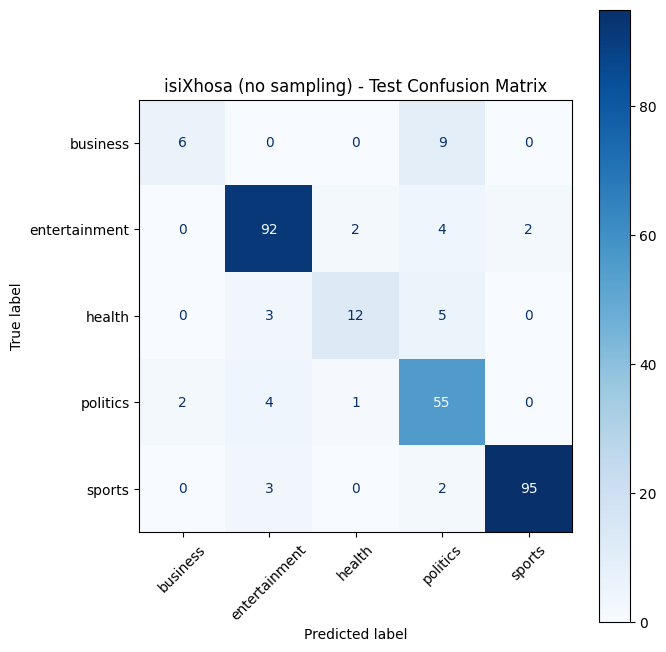

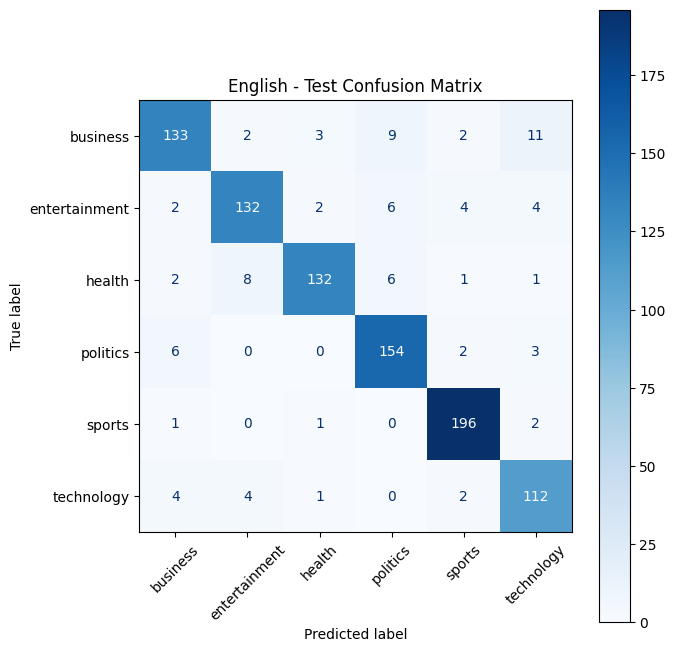

In [121]:
xho_final_test_loader = build_dataloaders(xho_final["tensors"], batch_size=16)[2]
plot_confusion_matrix(xho_final["model"], xho_final_test_loader, xho_final["tensors"]["label_encoder"], "isiXhosa (no sampling) - Test Confusion Matrix")

eng_final_test_loader = build_dataloaders(final_english["tensors"], batch_size=16)[2]
plot_confusion_matrix(final_english["model"], eng_final_test_loader, final_english["tensors"]["label_encoder"], "English - Test Confusion Matrix")

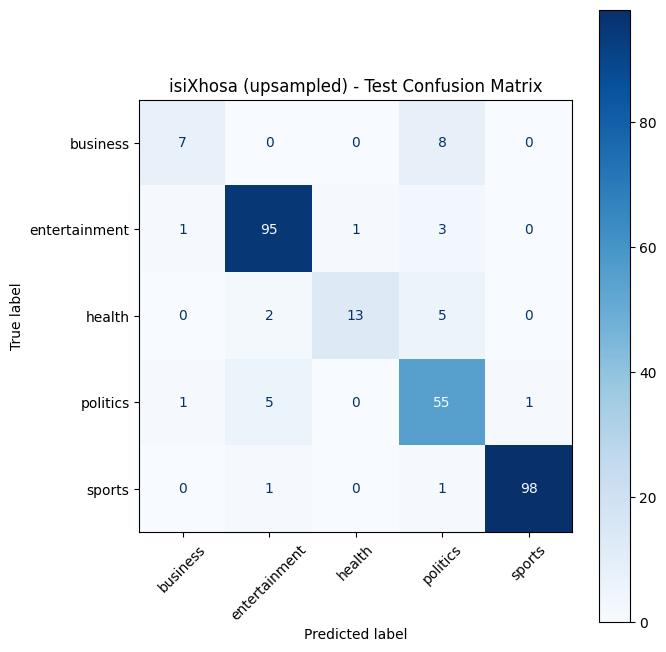

In [122]:
best_upsample_model = [r for r in upsample_results2 if r["boost_factor"] == 1.0][0]
upsample_test_loader = build_dataloaders(best_upsample_model["tensors"], batch_size=16)[2]
plot_confusion_matrix(
    best_upsample_model["model"], upsample_test_loader, best_upsample_model["tensors"]["label_encoder"],
    "isiXhosa (upsampled) - Test Confusion Matrix"
)

xho_sna_test_loader = build_dataloaders_from_arrays = None  

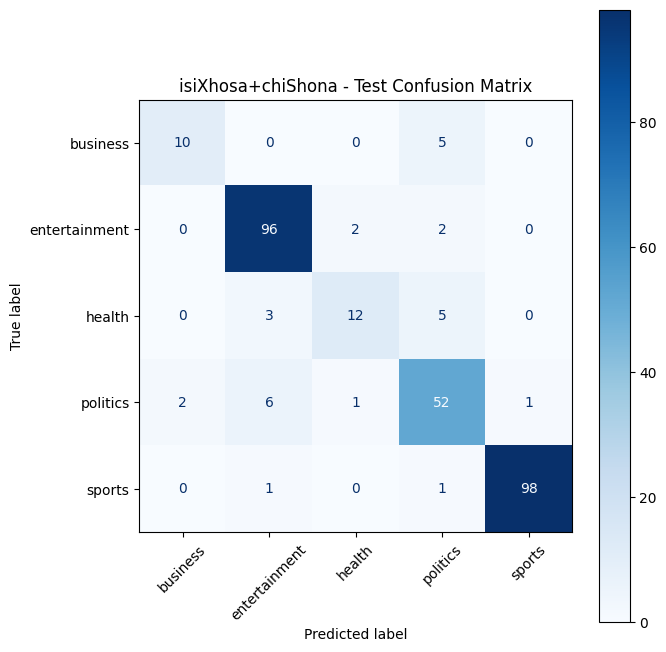

In [ ]:
cm = confusion_matrix(result_xho_sna["test_labels"], result_xho_sna["test_preds"],
                       labels=list(range(len(result_xho_sna["label_encoder"].classes_))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=result_xho_sna["label_encoder"].classes_)


fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("isiXhosa+chiShona - Test Confusion Matrix")
plt.tight_layout()
plt.show()